In [64]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df=pd.read_csv("customer.csv")
data=df
print(data.shape)
print(data.head())
print(data.columns)
print(data.dtypes)

(12, 3)
  Customer  Annual Income  Spending Score
0        A             15              20
1        B             18              25
2        C             20              18
3        D             22              30
4        E             50              75
Index(['Customer', 'Annual Income', 'Spending Score'], dtype='object')
Customer          object
Annual Income      int64
Spending Score     int64
dtype: object


In [70]:
X=data[["Annual Income","Spending Score"]]
for k in range(2,10):
    model=KMeans(n_clusters=k,random_state=0)
    labels=model.fit_predict(X)
    score=silhouette_score(X,labels)
    print(f"Clusters : {k}, Silhouette Score {k}: {score:.2f}")

Clusters : 2, Silhouette Score 2: 0.53
Clusters : 3, Silhouette Score 3: 0.85
Clusters : 4, Silhouette Score 4: 0.62
Clusters : 5, Silhouette Score 5: 0.62
Clusters : 6, Silhouette Score 6: 0.41
Clusters : 7, Silhouette Score 7: 0.15
Clusters : 8, Silhouette Score 8: 0.19
Clusters : 9, Silhouette Score 9: 0.14


In [72]:
print(data)

   Customer  Annual Income  Spending Score
0         A             15              20
1         B             18              25
2         C             20              18
3         D             22              30
4         E             50              75
5         F             55              80
6         G             60              72
7         H             65              85
8         I             85              25
9         J             90              20
10        K             88              30
11        L             95              28


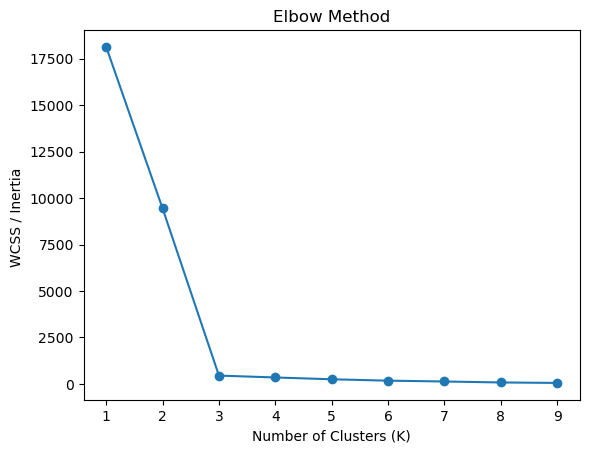

In [74]:
import matplotlib.pyplot as plt
X=data[["Annual Income","Spending Score"]]
wcss=[]
for k in range(1,10):
    model=KMeans(n_clusters=k,random_state=0)
    model.fit(X)
    wcss.append(model.inertia_)
plt.plot(range(1,10),wcss,marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia ")
plt.title("Elbow Method")
plt.show()
    

In [86]:
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=300,n_features=2,centers=3,random_state=42)
data=pd.DataFrame(X,columns=["Feature_1","Feature 2"])
print(data.shape)
print(data.head())


(300, 2)
   Feature_1  Feature 2
0  -7.338988  -7.729954
1  -7.740041  -7.264665
2  -1.686653   7.793442
3   4.422198   3.071947
4  -8.917752  -7.888196


In [94]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(data)
print(labels)
centroids=kmeans.cluster_centers_
print(centroids)

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0 0 0 2 1 0 1 1 2 2 0 0 0 1 0 1 0 1
 2 1 2 2 0 1 2 0 0 1 2 1 2 2 1 1 0 1 2 1 0 2 0 1 2 2 1 1 2 2 1 1 0 2 1 1 0
 0 1 1 2 0 2 0 0 1 0 2 1 1 0 2 0 1 0 1 0 0 1 1 0 1 1 2 0 2 0 0 0 0 0 2 1 2
 0 0 0 0 2 1 2 1 2 2 2 0 1 1 1 1 0 1 1 0 0 0 0 0 2 2 1 0 1 0 0 1 0 2 2 2 0
 2 0 0 1 2 1 0 2 2 1 1 0 0 1 1 1 0 1 2 0 0 0 0 0 2 0 2 2 2 0 2 2 1 0 1 2 2
 1 2 0 2 2 1 1 2 1 2 2 2 2 0 1 0 0 2 2 0 2 1 1 2 0 0 1 2 2 1 1 1 1 0 1 1 2
 1 1 0 2 1 1 2 0 0 1 0 1 2 2 1 2 1 1 1 2 2 0 1 2 2 2 1 2 1 2 1 2 2 1 2 0 1
 0 0 0 1 0 2 2 1 2 2 0 0 2 2 2 1 1 1 0 0 0 2 2 2 2 1 2 1 2 2 1 0 2 2 0 1 0
 2 0 1 1]
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


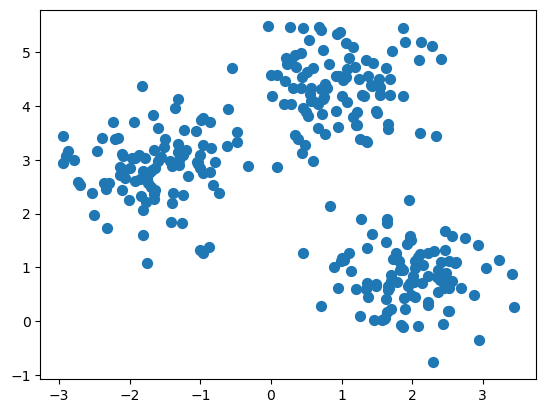

In [96]:
X,y=make_blobs(n_samples=300,centers=3,
               cluster_std=0.60,random_state=0)
plt.scatter(X[:,0],X[:,1],s=50)
plt.show()

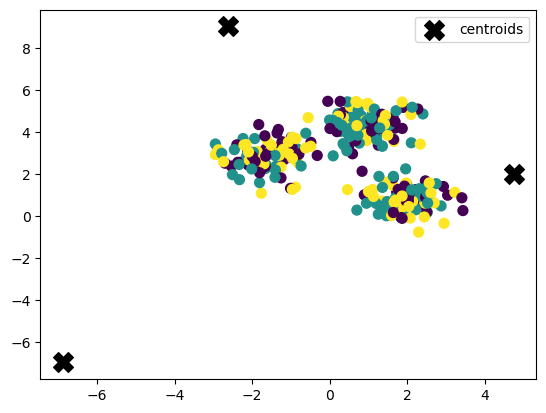

In [104]:
plt.scatter(X[:,0],X[:,1],c=kmeans.labels_,
            s=50,cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],
           s=200,marker="X",c="black",label="centroids")
plt.legend()
plt.show()

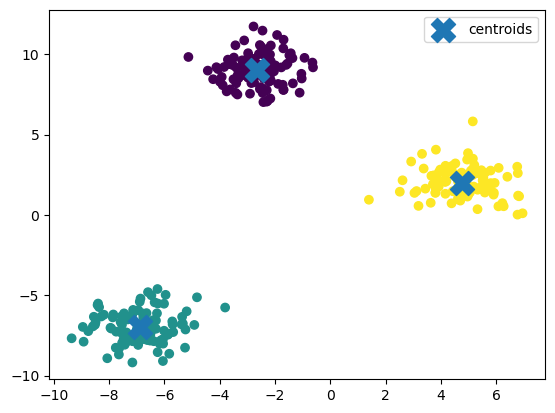

In [100]:
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    label="centroids"
)

plt.legend()
plt.show()